## Learning a Coordinate Transform (Representation Learning Demo)
This notebook demonstrates how a neural network can *learn* a simple coordinate transformation that makes data linearly separable.

### Generate a simple 2D dataset

In [1]:
# !pip install matplotlib numpy torch

import numpy as np
import matplotlib.pyplot as plt

# Fix random seed for reproducibility
np.random.seed(0)

# -------------------------------------------------------------
# 1. Generate a simple 2D dataset
# -------------------------------------------------------------
N = 400
X = np.random.randn(N, 2) * 0.8
# Two classes: divided by the line x + y = 0
y = (X[:, 0] + X[:, 1] > 0).astype(np.float32)

# Helper to compute classification accuracy given logits
def accuracy_from_logits(logits, labels):
    preds = (logits > 0).astype(np.float32)
    return (preds == labels).mean()




### Baseline decision: axis-aligned (x > 0)

In [2]:
# -------------------------------------------------------------
# 2. Baseline decision: axis-aligned (x > 0)
# -------------------------------------------------------------
baseline_logits = X[:, 0]
baseline_acc = accuracy_from_logits(baseline_logits, y)
print(f"Baseline (x > 0) accuracy: {baseline_acc:.3f}")


Baseline (x > 0) accuracy: 0.782


In [3]:
### 3. Manual coordinate rotation

In [4]:
theta = -np.pi / 4  # rotate by -45 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
X_rot = X.dot(R.T)

rotated_logits = X_rot[:, 0]  # use rotated x' coordinate
rotated_acc = accuracy_from_logits(rotated_logits, y)
print(f"Manual rotation (x' > 0) accuracy: {rotated_acc:.3f}")



Manual rotation (x' > 0) accuracy: 1.000


### Hand crafted "Neural Network" that learns its own transformation


In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Model parameters:
W = np.eye(2) + 0.1 * np.random.randn(2, 2)  # learnable transform (2x2)
v = np.random.randn(2) * 0.1                 # linear classifier (2,)
b = 0.0

lr = 0.5
epochs = 2000
for epoch in range(epochs):
    # Forward pass
    # print(f"X.shape:{X.shape}, W.T.shape: {W.T.shape}")
    Z = X.dot(W.T)
    # print(f"Z.shape: {Z.shape}, v.shape:{v.shape}, b: {b}")
    logits = Z.dot(v) + b
    probs = sigmoid(logits)

    # Binary cross-entropy loss
    loss = - (y * np.log(probs + 1e-9) + (1 - y) * np.log(1 - probs + 1e-9)).mean()

    # Gradients
    dL_dlogits = (probs - y) / N
    grad_v = Z.T.dot(dL_dlogits)
    grad_b = dL_dlogits.sum()
    grad_Z = np.outer(dL_dlogits, v).reshape(N, 2)
    grad_W = grad_Z.T.dot(X)

    # Parameter updates
    W -= lr * grad_W
    v -= lr * grad_v
    b -= lr * grad_b

    if epoch % 500 == 0:
        acc = accuracy_from_logits(logits, y)
        print(f"Epoch {epoch:4d}: loss={loss:.4f}, acc={acc:.4f}")



Epoch    0: loss=0.6586, acc=0.9025
Epoch  500: loss=0.0234, acc=1.0000
Epoch 1000: loss=0.0162, acc=1.0000
Epoch 1500: loss=0.0130, acc=1.0000


In [6]:
# -------------------------------------------------------------
# 5. Evaluate the learned model
# -------------------------------------------------------------
Z_final = X.dot(W.T)
logits_final = Z_final.dot(v) + b
final_acc = accuracy_from_logits(logits_final, y)
learned_rot_logits = Z_final[:, 0]
learned_rot_acc = accuracy_from_logits(learned_rot_logits, y)

print("\n--- Results ---")
print(f"Learned model accuracy: {final_acc:.3f}")
print(f"Using learned first coordinate (z₁ > 0): {learned_rot_acc:.3f}")
print("\nLearned W:\n", W)
print("\nManual rotation R:\n", R)

# Effective single-layer weight (w_eff = W^T v)
w_eff = W.T.dot(v)
print("\nEffective linear separator in original space (w_eff):\n", w_eff)




--- Results ---
Learned model accuracy: 1.000
Using learned first coordinate (z₁ > 0): 0.970

Learned W:
 [[4.39933164 3.5029947 ]
 [2.6779888  3.78066923]]

Manual rotation R:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Effective linear separator in original space (w_eff):
 [36.41202011 36.474981  ]


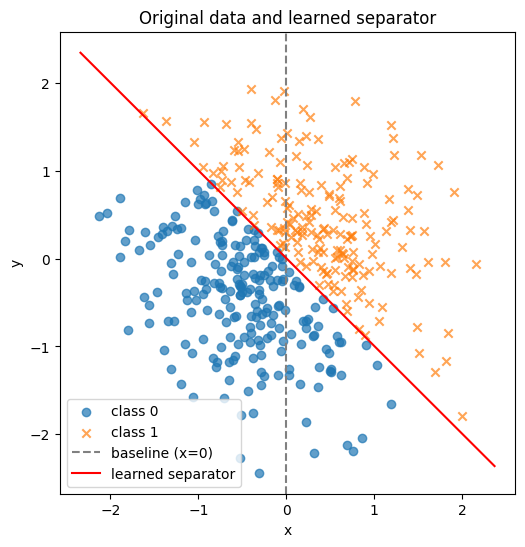

In [7]:
# -------------------------------------------------------------
# 6. Visualizations
# -------------------------------------------------------------
plt.figure(figsize=(6,6))
plt.title("Original data and learned separator")
plt.scatter(X[y==0,0], X[y==0,1], label="class 0", alpha=0.7)
plt.scatter(X[y==1,0], X[y==1,1], label="class 1", alpha=0.7, marker='x')

# Baseline boundary: x = 0
plt.axvline(0, color='gray', linestyle='--', label='baseline (x=0)')

# Learned boundary: w_eff[0]*x + w_eff[1]*y + b = 0
xmin, xmax = plt.xlim()
xs = np.linspace(xmin, xmax, 100)
ys = -(w_eff[0] * xs + b) / (w_eff[1] + 1e-9)
plt.plot(xs, ys, 'r-', label='learned separator')

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()



### Neural network using torch

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

N = 400
X_torch = torch.randn(N, 2) * 0.8
y_torch = (X_torch[:, 0] + X_torch[:, 1] > 0).float().view(-1, 1)  # labels in {0,1}

def accuracy(preds, labels):
    predicted = (preds > 0.5).float()
    return (predicted == labels).float().mean().item()

In [10]:


# -------------------------------------------------------------
# A simple neural network: 2D → (Linear Transform) → Sigmoid
# -------------------------------------------------------------
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.transform = nn.Linear(2, 2, bias=False)   # learnable coordinate transform W
        self.classifier = nn.Linear(2, 1)              # linear decision in transformed space
        self.activation = nn.Sigmoid()

    def forward(self, x):
        z = self.transform(x)
        out = self.activation(self.classifier(z))
        return out, z  # return both for visualization

model = SimpleNN()
optimizer = optim.SGD(model.parameters(), lr=0.5)
criterion = nn.BCELoss()

# -------------------------------------------------------------
# 5. Train the network
# -------------------------------------------------------------

for epoch in range(2000):
    optimizer.zero_grad()
    out, z = model(X_torch)
    loss = criterion(out, y_torch)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        acc = accuracy(out, y_torch)
        print(f"Epoch {epoch:4d}  loss={loss.item():.4f}  acc={acc:.4f}")

final_acc = accuracy(model(X_torch)[0], y_torch)
print(f"\nFinal learned model accuracy: {final_acc:.3f}")


Epoch    0  loss=0.5984  acc=0.8875
Epoch  500  loss=0.0265  acc=1.0000
Epoch 1000  loss=0.0168  acc=1.0000
Epoch 1500  loss=0.0129  acc=1.0000

Final learned model accuracy: 1.000



Learned transform W:
 tensor([[ 5.2691,  4.9662],
        [-1.8005, -2.3815]])

Manual rotation matrix R:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Classifier weights v:
 tensor([ 7.1968, -2.9539])


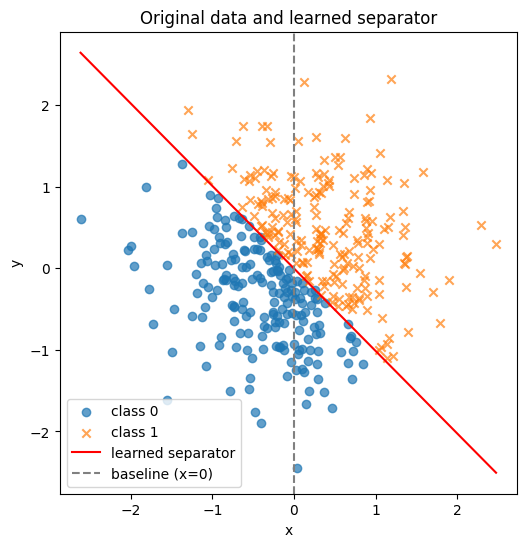

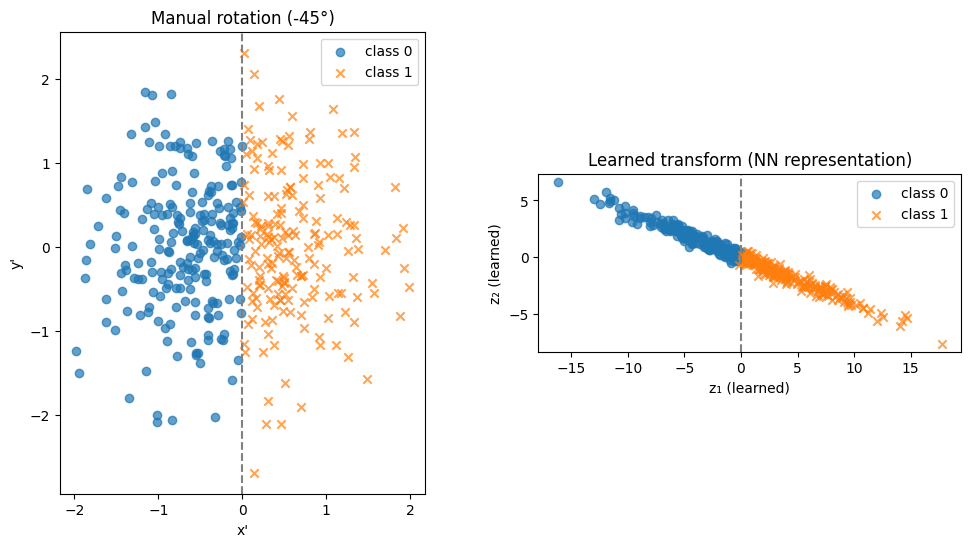

In [16]:
# Extract learned weights
with torch.no_grad():
    W_learned = model.transform.weight.detach().clone()
    b_learned = model.classifier.bias.item()
    v_learned = model.classifier.weight.detach().clone().view(-1)
    z_final = X_torch @ W_learned.T

print("\nLearned transform W:\n", W_learned)
print("\nManual rotation matrix R:\n", R)
print("\nClassifier weights v:\n", v_learned)

# -------------------------------------------------------------
# Plot original data with learned separator
# -------------------------------------------------------------
plt.figure(figsize=(6,6))
plt.title("Original data and learned separator")
plt.scatter(X_torch[y_torch.squeeze()==0,0], X_torch[y_torch.squeeze()==0,1], label="class 0", alpha=0.7)
plt.scatter(X_torch[y_torch.squeeze()==1,0], X_torch[y_torch.squeeze()==1,1], label="class 1", alpha=0.7, marker='x')

# Learned separator in input space: effective weight = W^T * v
w_eff = W_learned.T @ v_learned.view(-1,1)
w_eff = w_eff.view(-1).numpy()
xs = torch.linspace(X_torch[:,0].min(), X_torch[:,0].max(), 100)
ys = -(w_eff[0]*xs + b_learned) / (w_eff[1] + 1e-6)
plt.plot(xs, ys, 'r-', label='learned separator')
plt.axvline(0, color='gray', linestyle='--', label='baseline (x=0)')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# -------------------------------------------------------------
# Plot transformed coordinates
# -------------------------------------------------------------
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Manual rotation
axes[0].set_title("Manual rotation (-45°)")
axes[0].scatter(X_rot[y.squeeze()==0,0], X_rot[y.squeeze()==0,1], label="class 0", alpha=0.7)
axes[0].scatter(X_rot[y.squeeze()==1,0], X_rot[y.squeeze()==1,1], label="class 1", alpha=0.7, marker='x')
axes[0].axvline(0, color='gray', linestyle='--')
axes[0].set_xlabel("x'")
axes[0].set_ylabel("y'")
axes[0].legend()
axes[0].set_aspect('equal')

# Learned transform
axes[1].set_title("Learned transform (NN representation)")
axes[1].scatter(z_final[y_torch.squeeze()==0,0], z_final[y_torch.squeeze()==0,1], label="class 0", alpha=0.7)
axes[1].scatter(z_final[y_torch.squeeze()==1,0], z_final[y_torch.squeeze()==1,1], label="class 1", alpha=0.7, marker='x')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_xlabel("z₁ (learned)")
axes[1].set_ylabel("z₂ (learned)")
axes[1].legend()
axes[1].set_aspect('equal')

plt.show()


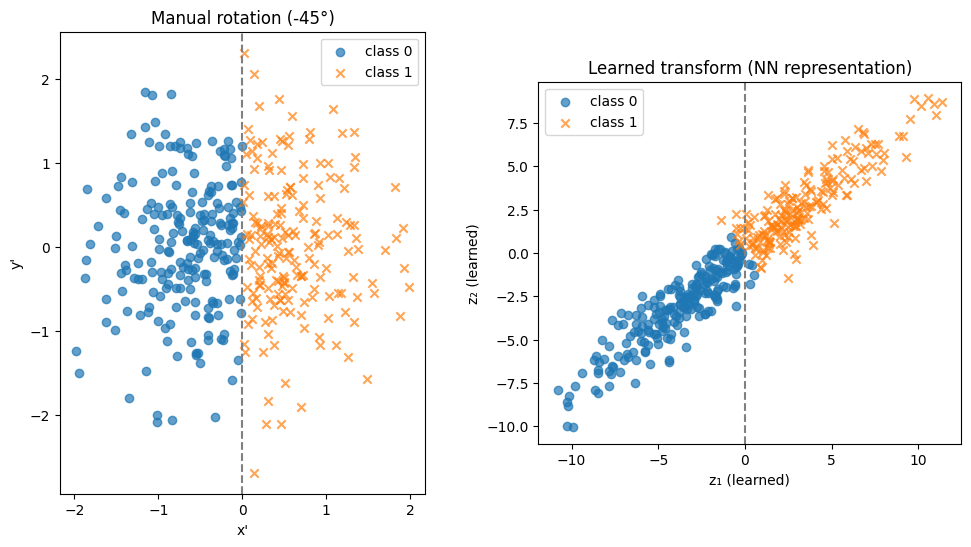

In [15]:
# -------------------------------------------------------------
# Show transformed spaces
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Manual rotation
axes[0].set_title("Manual rotation (-45°)")
axes[0].scatter(X_rot[y==0,0], X_rot[y==0,1], label="class 0", alpha=0.7)
axes[0].scatter(X_rot[y==1,0], X_rot[y==1,1], label="class 1", alpha=0.7, marker='x')
axes[0].axvline(0, color='gray', linestyle='--')
axes[0].set_xlabel("x'")
axes[0].set_ylabel("y'")
axes[0].legend()
axes[0].set_aspect('equal')

# Learned transform
axes[1].set_title("Learned transform (NN representation)")
axes[1].scatter(Z_final[y==0,0], Z_final[y==0,1], label="class 0", alpha=0.7)
axes[1].scatter(Z_final[y==1,0], Z_final[y==1,1], label="class 1", alpha=0.7, marker='x')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_xlabel("z₁ (learned)")
axes[1].set_ylabel("z₂ (learned)")
axes[1].legend()
axes[1].set_aspect('equal')

plt.show()